# CLUSTERING - TS

In [259]:
import pandas as pd
import numpy as np
import pycatch22
from pycatch22 import catch22_all
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import seaborn as sns

In [260]:
df = pd.read_csv("df_finale.csv")

In [261]:
g = [c for c in df.columns if c.startswith("genre_")]
df_clus = df.drop(g, axis=1)
df_clus = df_clus.drop("rating_category", axis=1)

In [262]:
df_clus

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,rating
0,3.203808,3.310528,3.080549,2.714583,2.409941,1.993775,1.583635,1.246871,0.796810,0.508554,...,-0.773251,-0.785931,-0.803325,-0.819292,-0.826546,-0.800523,-0.780994,-0.758548,-0.731235,-1.703993
1,1.641869,1.789420,1.837915,1.826346,1.841613,1.608536,1.322736,1.058922,0.766201,0.509104,...,0.091804,-0.046413,-0.296589,-0.555315,-0.811598,-0.923964,-0.900554,-0.895424,-0.931546,-1.961981
2,2.146533,2.074483,1.922000,1.688202,1.367001,1.099541,0.879503,0.663925,0.466093,0.366285,...,-0.758995,-0.769806,-0.782269,-0.789811,-0.797837,-0.803927,-0.801292,-0.798581,-0.795879,-0.890415
3,1.244228,0.974971,0.792436,0.658828,0.110609,-0.230373,-0.290343,-0.352859,-0.421936,-0.490316,...,-0.366959,-0.498499,-0.525716,-0.548996,-0.568911,-0.587338,-0.602909,-0.612658,-0.613246,-0.619720
4,2.958126,2.791581,2.692438,2.631157,2.300224,2.052480,1.904554,1.740678,1.606702,1.489338,...,-0.646453,-0.645161,-0.645457,-0.647903,-0.651366,-0.656044,-0.661063,-0.665579,-0.668798,-0.680769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1129,3.930861,3.678304,3.339795,2.963937,2.483528,2.027932,1.564115,1.153334,0.836055,0.641848,...,-0.582350,-0.584734,-0.588441,-0.591204,-0.592680,-0.593513,-0.593650,-0.593869,-0.594236,-0.603271
1130,2.917085,2.810270,2.618698,2.314326,2.073896,2.056742,1.890531,1.667496,1.459727,1.321335,...,-0.688884,-0.696743,-0.702418,-0.706121,-0.709908,-0.710889,-0.710866,-0.709265,-0.704758,-0.758509
1131,3.558092,3.264517,2.947922,2.588963,2.087472,1.656590,1.244943,0.928361,0.700896,0.570797,...,-0.547282,-0.579174,-0.602577,-0.644120,-0.707286,-0.765331,-0.802150,-0.828583,-0.841612,-1.037824
1132,3.468692,3.669017,3.510363,3.077339,2.725131,2.253547,1.699255,1.092181,0.427260,0.010953,...,-0.486256,-0.508885,-0.540992,-0.570104,-0.590912,-0.601979,-0.604438,-0.608394,-0.614915,-0.651670


In [263]:
features = []
ids = []

# Itera sulle RIGHE, non sulle colonne
for idx, row in df_clus.iterrows():
    feats = catch22_all(row.values)["values"]  # .values per convertire la Series in array
    features.append(feats)
    ids.append(idx)  # idx sarà l'indice della riga

# Usa la prima riga per ottenere i nomi delle feature
feature_names = catch22_all(df_clus.iloc[0].values)["names"]

# Resto del codice
df_features = pd.DataFrame(features, columns=feature_names)
df_features.insert(0, "id", ids)

df_features["mean"] = df_features.drop(columns=["id"]).mean(axis=1)
df_features["std"] = df_features.drop(columns=["id"]).std(axis=1)

X_feats = df_features.drop(columns=["id"])
print(X_feats.shape)  # Dovrebbe essere (1134, 24)

(1134, 24)


In [264]:
X_feats = df_features.drop(columns=["id"])

In [265]:
X_feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Data columns (total 24 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   DN_HistogramMode_5                           1134 non-null   float64
 1   DN_HistogramMode_10                          1134 non-null   float64
 2   CO_f1ecac                                    1134 non-null   float64
 3   CO_FirstMin_ac                               1134 non-null   int64  
 4   CO_HistogramAMI_even_2_5                     1134 non-null   float64
 5   CO_trev_1_num                                1134 non-null   float64
 6   MD_hrv_classic_pnn40                         1134 non-null   float64
 7   SB_BinaryStats_mean_longstretch1             1134 non-null   float64
 8   SB_TransitionMatrix_3ac_sumdiagcov           1134 non-null   float64
 9   PD_PeriodicityWang_th0_01                    1134 non-null   int64  
 10  

In [266]:
scaler = MinMaxScaler()
X_feats = scaler.fit_transform(X_feats)

### K-MEANS with EUCLIDEAN DISTANCE

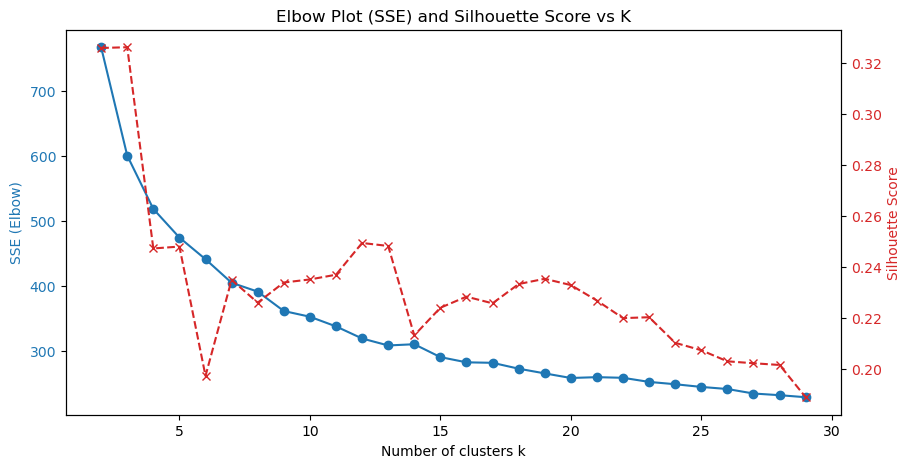

In [267]:
# ====================================
# 4. Calcolo SSE e Silhouette per diversi K
# ====================================
sse = []
sil_scores = []
K = range(2, 30)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_feats)
    sse.append(kmeans.inertia_)  # SSE (sum of squared distances)
    sil_scores.append(silhouette_score(X_feats, labels))


fig, ax1 = plt.subplots(figsize=(10,5))
color = 'tab:blue'
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('SSE (Elbow)', color=color)
ax1.plot(K, sse, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K, sil_scores, marker='x', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Elbow Plot (SSE) and Silhouette Score vs K")
plt.show()

In [268]:
# clustering finale
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_feats)

df_features["cluster_kmeans"] = labels
df["cluster_kmeans"] = labels

In [269]:
df_features["cluster_kmeans"].value_counts()

cluster_kmeans
0    497
3    260
2    190
1    187
Name: count, dtype: int64

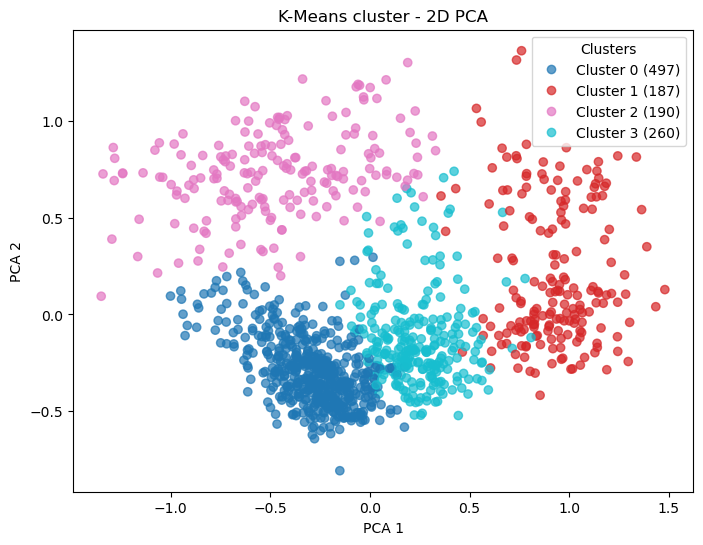

In [270]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Riduzione a 2 componenti per visualizzazione
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_feats)

# Conteggio dei punti per cluster
cluster_counts = Counter(labels)  # labels = array dei cluster assegnati

plt.figure(figsize=(8,6))

# Scatter plot
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', alpha=0.7)

# Creazione manuale delle etichette della legenda con numero di elementi
handles, _ = scatter.legend_elements()
labels_legend = [f"Cluster {i} ({cluster_counts[i]})" for i in range(len(handles))]

plt.legend(handles, labels_legend, title="Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means cluster - 2D PCA")
plt.show()


c:\Users\Gagia\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


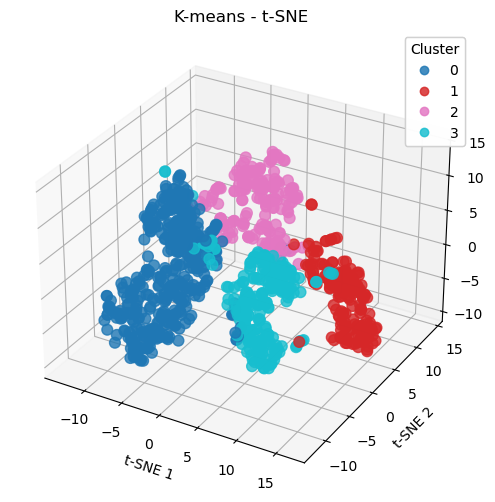

In [271]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np

np.random.seed(42)

y = df_features["cluster_kmeans"]

# t-SNE 3D
tsne = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42)
X_tsne_3d = tsne.fit_transform(X_feats)

# Plot 3D
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot 3D
scatter = ax.scatter(
    X_tsne_3d[:,0], X_tsne_3d[:,1], X_tsne_3d[:,2],
    c=y, cmap='tab10', s=60, alpha=0.8
)

# Legenda e titoli
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
ax.set_title("K-means - t-SNE")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")

plt.show()


### Trend and Seasonality analysis of clusters


=== Cluster 0 ===


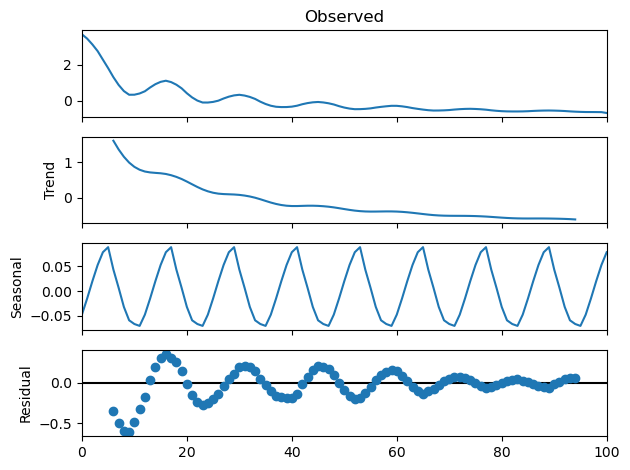


=== Cluster 2 ===


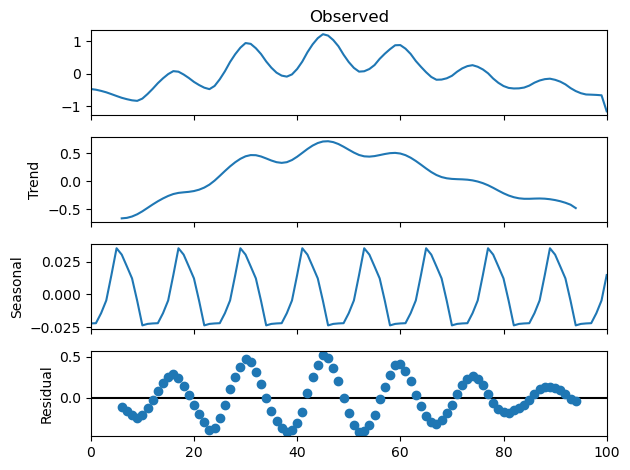


=== Cluster 3 ===


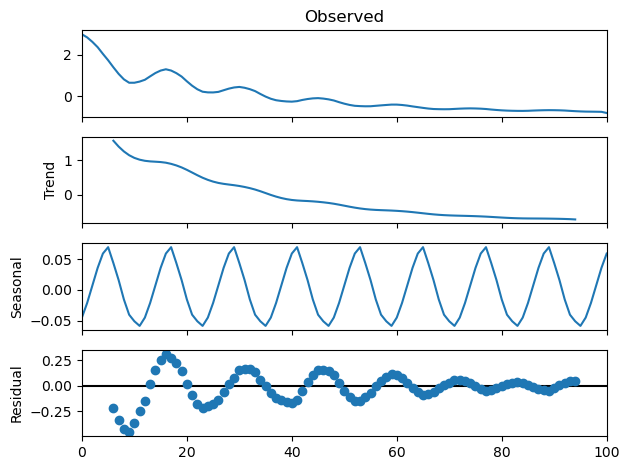


=== Cluster 1 ===


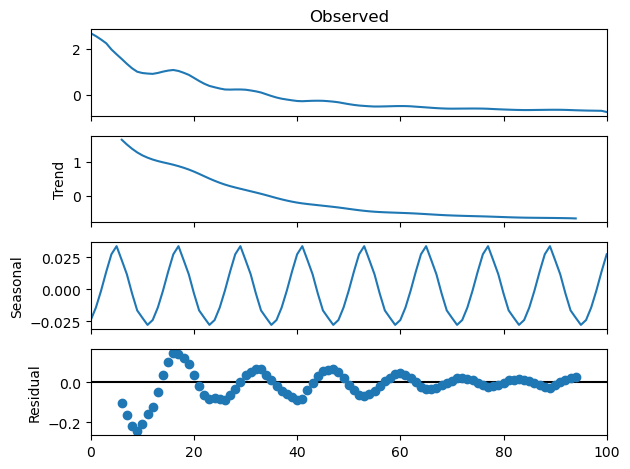

In [273]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

clusters = df_features["cluster_kmeans"].unique()

for cluster_id in clusters:
    print(f"\n=== Cluster {cluster_id} ===")
    
    # prendo gli id delle serie nel cluster
    ts_ids = df_features[df_features["cluster_kmeans"] == cluster_id]["id"]
    
    # estraggo le serie originali (righe di df)
    series_in_cluster = [df_clus.loc[ts_id].values for ts_id in ts_ids]
    
    # allineo in matrice
    cluster_matrix = np.vstack(series_in_cluster)
    
    # serie media del cluster
    cluster_mean = cluster_matrix.mean(axis=0)
    
    # decomposizione stagionale (scegli il periodo in base ai tuoi dati, es. 12, 24...)
    result = seasonal_decompose(cluster_mean, model="additive", period=12)
    
    fig = result.plot()
    # fig.suptitle(f"Cluster {cluster_id} - Decomposizione", fontsize=14)
    plt.show()


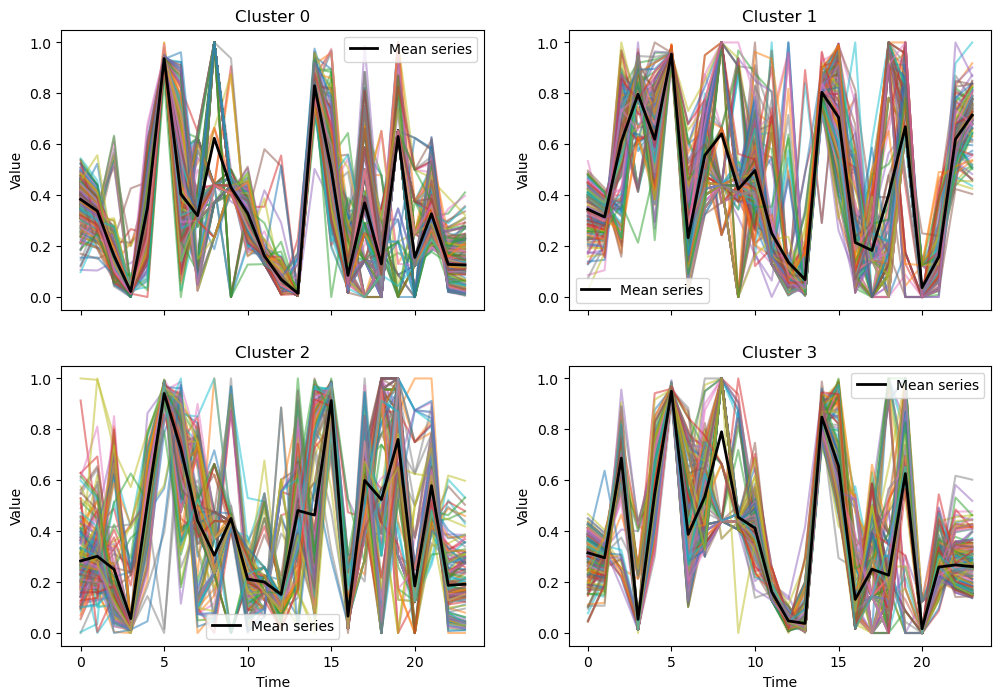

In [274]:
n_clusters = len(np.unique(labels))

# Creiamo una griglia 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # per iterare facilmente sugli assi

for cluster in range(n_clusters):
    ax = axes[cluster]
    cluster_series = X_feats[labels == cluster]  # selezioniamo le serie del cluster corrente
    
    # plottiamo tutte le serie con trasparenza
    for ts in cluster_series:
        ax.plot(ts, alpha=0.5)
    
    # plottiamo la media del cluster
    mean_ts = np.mean(cluster_series, axis=0)
    ax.plot(mean_ts, color='black', linewidth=2, label='Mean series')
    
    ax.set_title(f"Cluster {cluster}")
    
    # Mostriamo l'etichetta x solo per la riga inferiore (subplot 2 e 3 nell'array flatten)
    if cluster >= 2:  
        ax.set_xlabel("Time")
    else:
        ax.set_xticklabels([])  # nasconde le etichette x
    
    ax.set_ylabel("Value")
    ax.legend()

### HIERARCHICAL CLUSTERING

In [275]:
# ======================
# 2. Clustering gerarchico
# ======================

Z = linkage(X_feats, method="ward")


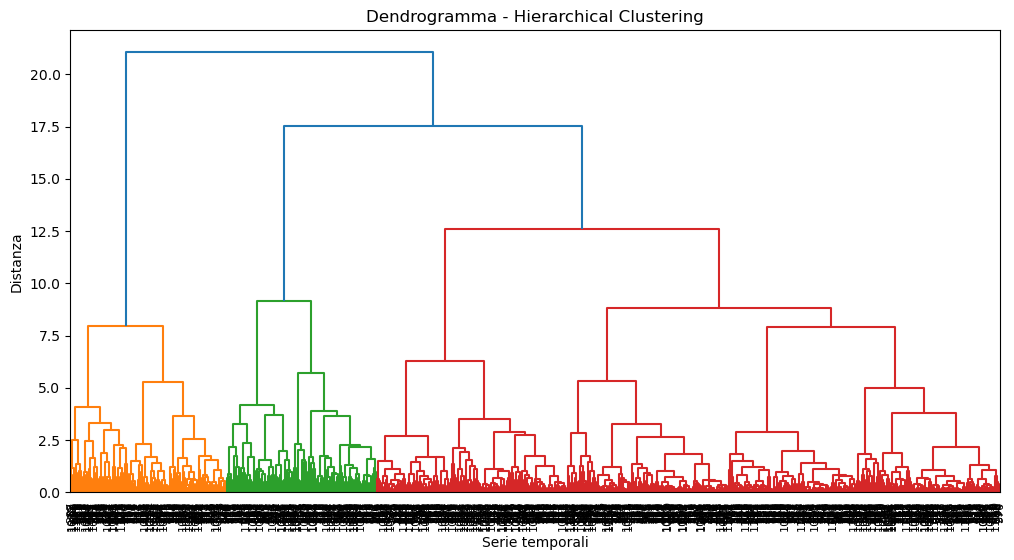

In [276]:
# ======================
# 3. Visualizzazione dendrogramma
# ======================
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=df_features["id"].values, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogramma - Hierarchical Clustering")
plt.xlabel("Serie temporali")
plt.ylabel("Distanza")
plt.show()

In [277]:
# ======================
# 4. Estrazione cluster
# ======================
# tagliare l’albero a una certa distanza -> k cluster
k = 4  # numero di cluster desiderati
clusters = fcluster(Z, k, criterion="maxclust")

# Aggiungo l’etichetta dei cluster al DataFrame
df_features["cluster_hierarchical"] = clusters
df["cluster_hierarchical"] = clusters

In [278]:
df_features["cluster_hierarchical"].value_counts()

cluster_hierarchical
4    528
3    233
1    191
2    182
Name: count, dtype: int64

c:\Users\Gagia\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


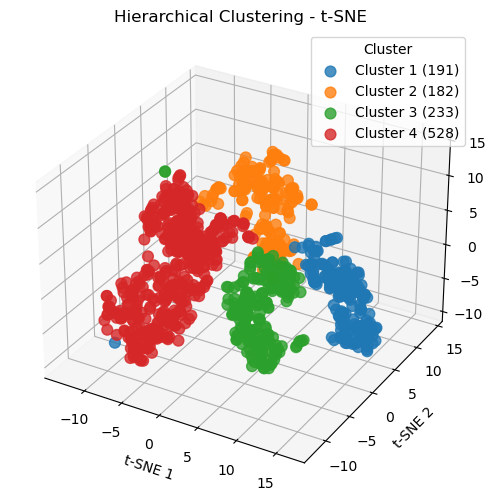

In [279]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np
import pandas as pd

np.random.seed(42)

y = df_features["cluster_hierarchical"]
clusters = np.unique(y)

# t-SNE 3D
tsne = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42)
X_tsne_3d = tsne.fit_transform(X_feats)

# Plot 3D
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot 3D
colors = plt.cm.tab10.colors  # palette per cluster
for i, cluster in enumerate(clusters):
    idx = y == cluster
    ax.scatter(
        X_tsne_3d[idx,0], X_tsne_3d[idx,1], X_tsne_3d[idx,2],
        c=[colors[i]], s=60, alpha=0.8, label=f'Cluster {cluster} ({np.sum(idx)})'
    )

# Legenda e titoli
ax.legend(title="Cluster")
ax.set_title("Hierarchical Clustering - t-SNE")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")

plt.show()



=== Cluster 4 ===


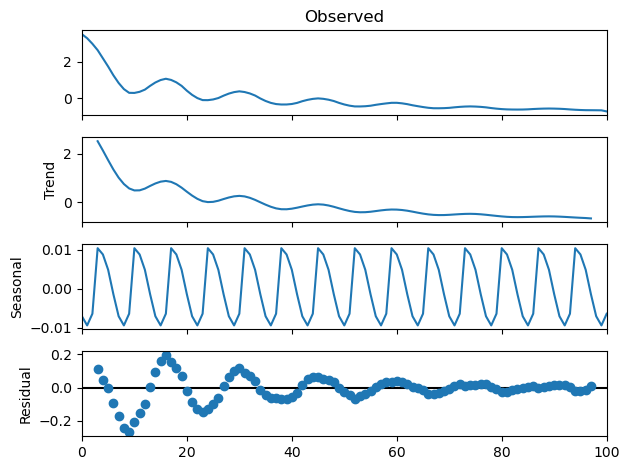


=== Cluster 2 ===


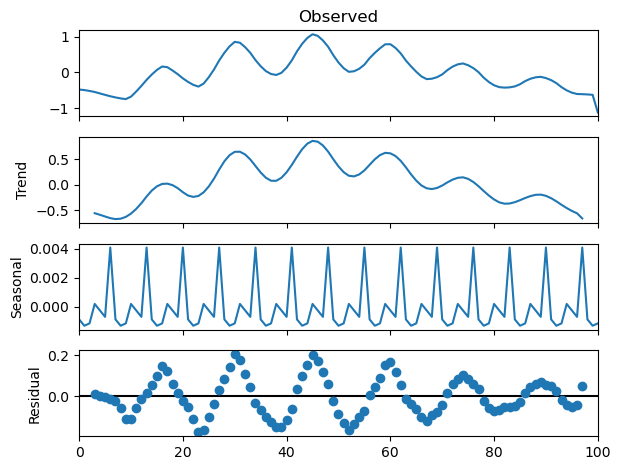


=== Cluster 1 ===


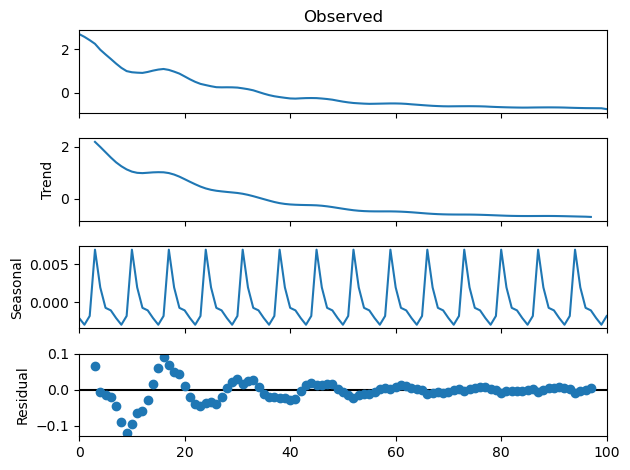


=== Cluster 3 ===


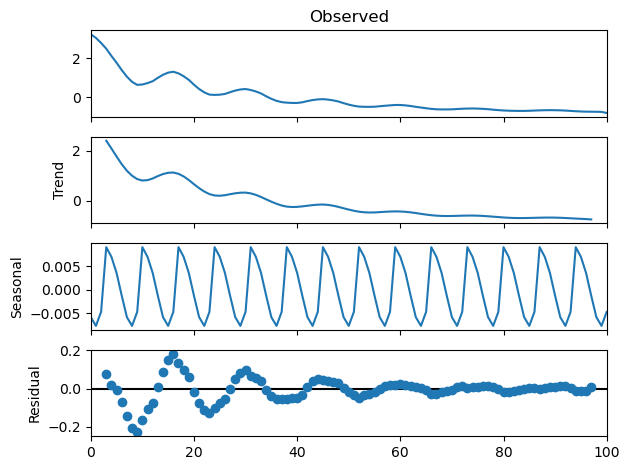

In [281]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

clusters = df_features["cluster_hierarchical"].unique()

for cluster_id in clusters:
    print(f"\n=== Cluster {cluster_id} ===")
    
    # prendo gli id delle serie nel cluster
    ts_ids = df_features[df_features["cluster_hierarchical"] == cluster_id]["id"]
    
    # estraggo le serie originali (righe di df)
    series_in_cluster = [df_clus.loc[ts_id].values for ts_id in ts_ids]
    
    # allineo in matrice
    cluster_matrix = np.vstack(series_in_cluster)
    
    # serie media del cluster
    cluster_mean = cluster_matrix.mean(axis=0)
    
    # decomposizione stagionale (scegli il periodo in base ai tuoi dati, es. 12, 24...)
    result = seasonal_decompose(cluster_mean, model="additive", period=7)
    
    fig = result.plot()
    # fig.suptitle(f"Cluster {cluster_id} - Decomposizione", fontsize=14)
    plt.show()


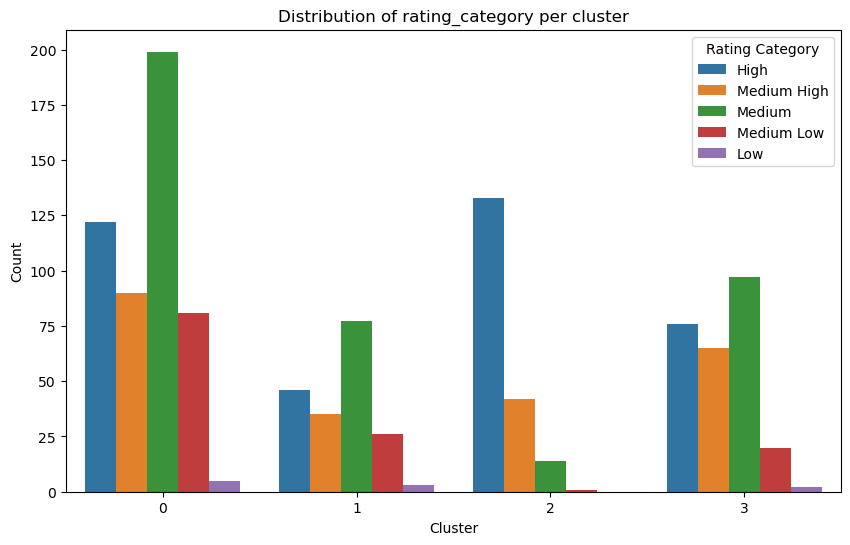

In [284]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grafico della distribuzione di rating_category per cluster
plt.figure(figsize=(10,6))
sns.countplot(data=df, x=df['cluster_kmeans'], hue=df['rating_category'])
plt.title("Distribution of rating_category per cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title='Rating Category')
plt.show()


In [287]:
x = df["rating_category"].groupby(df["cluster_hierarchical"]).value_counts()
x

cluster_hierarchical  rating_category
1                     Medium              79
                      High                47
                      Medium High         36
                      Medium Low          25
                      Low                  4
2                     High               126
                      Medium High         39
                      Medium              14
                      Medium Low           3
3                     Medium              87
                      High                74
                      Medium High         56
                      Medium Low          16
4                     Medium             207
                      High               130
                      Medium High        101
                      Medium Low          84
                      Low                  6
Name: count, dtype: int64